Affine Transformation Matrix (M):
[[  1.03776472   0.16838046 -69.22040641]
 [ -0.18150936   1.13560411  -5.55572898]]

Unknown affine parameters (X = [a1 b1 a0 a2 b2 b0]):
[ 739.49403903  594.7043815  -205.67990483 -165.49515276 -180.8141342
 -145.20922874]


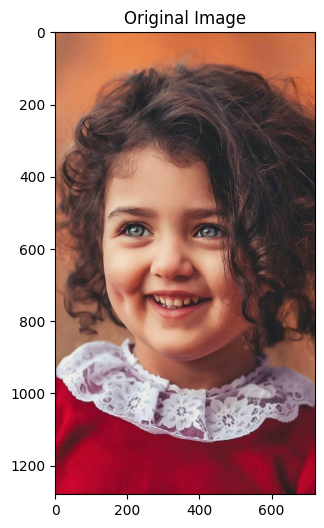

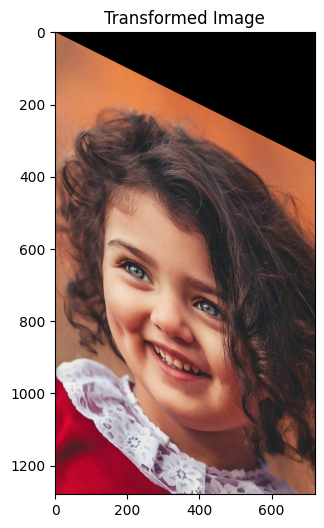

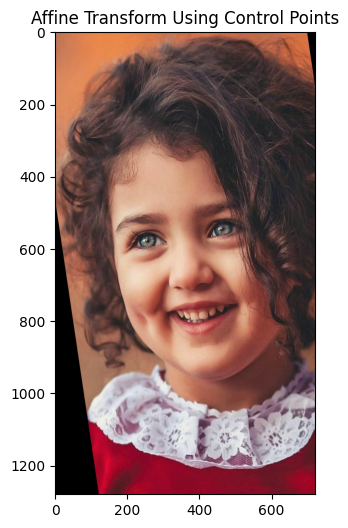

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# --- Load original image ---
I = cv2.imread('pk.jpg')
I = cv2.cvtColor(I, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(6,6))
plt.imshow(I)
plt.title('Original Image')
plt.axis('on')

# --- Apply an affine transformation ---
rows, cols = I.shape[:2]
tform = np.float32([[1, 0, 0],
                    [0.5, 1, 0]])  # same as MATLAB matrix [1 0 0; .5 1 0; 0 0 1]
J = cv2.warpAffine(I, tform, (cols, rows))

plt.figure(figsize=(6,6))
plt.imshow(J)
plt.title('Transformed Image')
plt.axis('on')

# ======================================================
# Manual control points (equivalent to cpselect)
# ======================================================
# Points from original image (x, y)
moving_points = np.float32([
    [164, 113],
    [353, 130],
    [143, 284]
])

# Points from transformed image (u, v)
fixed_points = np.float32([
    [120, 93],
    [319, 78],
    [127, 291]
])

# ======================================================
# Compute affine transform using cv2.getAffineTransform
# ======================================================
M = cv2.getAffineTransform(moving_points, fixed_points)
print("Affine Transformation Matrix (M):")
print(M)

# Apply this affine transform
J2 = cv2.warpAffine(I, M, (cols, rows))
plt.figure(figsize=(6,6))
plt.imshow(J2)
plt.title('Affine Transform Using Control Points')
plt.axis('on')

# ======================================================
# Manual computation of affine parameters (like MATLAB)
# ======================================================
# Matrix A (based on point correspondences)
A = np.array([
    [120, 93, 1, 0, 0, 0],
    [0, 0, 0, 120, 93, 1],
    [319, 78, 1, 0, 0, 0],
    [0, 0, 0, 319, 78, 1],
    [127, 291, 1, 0, 0, 0],
    [0, 0, 0, 127, 291, 1]
], dtype=float)

# B = [x0 y0 x1 y1 x2 y2] from original image
B = np.array([164, 113, 353, 130, 143, 284], dtype=float)

# Compute X = inv(A) * B
x = np.linalg.inv(A)
X = B @ x

print("\nUnknown affine parameters (X = [a1 b1 a0 a2 b2 b0]):")
print(X)
